# InsightForge: AI-Powered Business Intelligence Assistant

This notebook builds a full RAG + Pandas Agent BI assistant using LangChain, FAISS, and Claude (Anthropic).

**Dataset:** `sales_data.csv` — 2,500 daily sales records (2022–2028)  
**Architecture:** FAISS vector store for semantic retrieval + Pandas Agent for numeric queries  

---
## Notebook Structure
- **Cell 1:** Install dependencies
- **Cell 2:** Imports & API key setup
- **Cell 3:** Load & explore dataset
- **Cell 4:** Build FAISS knowledge base
- **Cell 5:** Build Pandas Agent
- **Cell 6:** Build RAG chain
- **Cell 7:** Router + unified query interface (with memory)
- **Cell 8:** Advanced data summary
- **Cell 9:** Model evaluation with QAEvalChain
- **Cell 10:** Data visualizations
- **Cell 11:** Streamlit UI launcher

---
## Cell 1: Install Dependencies

In [ ]:
# Run this cell once. Restart the kernel after it finishes.

import subprocess, sys
packages = [
    "langchain>=0.3,<1.0",
    "langchain-anthropic>=0.3,<1.0",
    "langchain-community>=0.3,<1.0",
    "langchain-experimental>=0.3,<1.0",
    "langchain-core>=0.3,<1.0",
    "onnxruntime>=1.16,<1.20",   # 1.20+ has DLL_INIT_FAILED in Jupyter on Windows
    "fastembed",
    "faiss-cpu",
    "anthropic",
    "python-dotenv",
    "pandas",
    "matplotlib",
    "seaborn",
    "tabulate",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)
print("All packages installed. Restart the kernel before continuing.")

---
## Cell 2: Imports & API Key Setup

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import onnxruntime  # noqa: F401  — must import before pandas (avoids MKL DLL conflict)
import fastembed    # noqa: F401

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from dotenv import load_dotenv

# LangChain core
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate

# LangChain chains & memory
from langchain.chains import RetrievalQA, ConversationalRetrievalChain
from langchain.memory import ConversationBufferMemory

# LangChain integrations
from langchain_anthropic import ChatAnthropic
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import FastEmbedEmbeddings
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain.agents.agent_types import AgentType

# ── API key ──────────────────────────────────────────────────────────────────
load_dotenv()
api_key = os.getenv("ANTHROPIC_API_KEY")

if not api_key:
    raise ValueError(
        "ANTHROPIC_API_KEY not found. "
        "Create a file named .env in the same folder as this notebook, "
        "containing the line:  ANTHROPIC_API_KEY=sk-ant-..."
    )

print(f"API key loaded: {api_key[:12]}...")

# ── LLM ──────────────────────────────────────────────────────────────────────
llm = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    anthropic_api_key=api_key,
    temperature=0,
    max_tokens=2048
)

print("LLM initialised: Claude Haiku (fast & cost-effective for development)")
print("Tip: change model to claude-sonnet-4-6 for production use.")

API key loaded: sk-ant-api03...
LLM initialised: Claude Haiku (fast & cost-effective for development)
Tip: change model to claude-sonnet-4-6 for production use.


---
## Cell 3: Load & Explore Dataset

> **Step 1 & 2 of the capstone:** Data preparation and knowledge base creation begin here.

In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv("sales_data.csv", parse_dates=["Date"])

# Derive useful time columns for analysis
df["Year"]    = df["Date"].dt.year
df["Month"]   = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["YearMonth"] = df["Date"].dt.to_period("M")

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape:        {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range:   {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Products:     {sorted(df['Product'].unique())}")
print(f"Regions:      {sorted(df['Region'].unique())}")
print(f"Genders:      {sorted(df['Customer_Gender'].unique())}")
print(f"Age range:    {df['Customer_Age'].min()} – {df['Customer_Age'].max()} years")
print(f"Sales range:  ${df['Sales'].min():,} – ${df['Sales'].max():,}")
print()
print("── Dtypes ──────────────────────────────────────")
print(df.dtypes)
print()
print("── Descriptive Statistics ───────────────────────")
display(df[["Sales", "Customer_Age", "Customer_Satisfaction"]].describe().round(2))
print()
print("── First 5 rows ──────────────────────────────────")
display(df.head())

DATASET OVERVIEW
Shape:        2,500 rows × 11 columns
Date range:   2022-01-01 → 2028-11-04
Products:     ['Widget A', 'Widget B', 'Widget C', 'Widget D']
Regions:      ['East', 'North', 'South', 'West']
Genders:      ['Female', 'Male']
Age range:    18 – 69 years
Sales range:  $100 – $999

── Dtypes ──────────────────────────────────────
Date                     datetime64[ns]
Product                          object
Region                           object
Sales                             int64
Customer_Age                      int64
Customer_Gender                  object
Customer_Satisfaction           float64
Year                              int32
Month                             int32
Quarter                           int32
YearMonth                     period[M]
dtype: object

── Descriptive Statistics ───────────────────────


,Sales,Customer_Age,Customer_Satisfaction
count,2500.00,2500.00,2500.00
mean,553.29,43.33,3.03
std,260.10,14.85,1.16
min,100.00,18.00,1.01
25%,324.75,31.00,2.06
50%,552.50,43.00,3.05
75%,779.00,56.00,4.04
max,999.00,69.00,5.00



── First 5 rows ──────────────────────────────────


,Date,Product,Region,Sales,Customer_Age,Customer_Gender,Customer_Satisfaction,Year,Month,Quarter,YearMonth
0,2022-01-01,Widget C,South,786,26,Male,2.874407,2022,1,1,2022-01
1,2022-01-02,Widget D,East,850,29,Male,3.365205,2022,1,1,2022-01
2,2022-01-03,Widget A,North,871,40,Female,4.547364,2022,1,1,2022-01
3,2022-01-04,Widget C,South,464,31,Male,4.555420,2022,1,1,2022-01
4,2022-01-05,Widget C,South,262,50,Female,3.982935,2022,1,1,2022-01


---
## Cell 4: Build FAISS Knowledge Base

> **Step 2 (continued) & Step 5:** Organise data into a retrieval-ready format and set up the RAG system.

In [3]:
# ── Step 4a: Build the static knowledge base documents ───────────────────────
# The knowledge base stores KPI definitions, analysis formulas, approved patterns,
# reporting guidelines, and column mappings. The Pandas Agent handles all exact
# numeric queries directly against the DataFrame, so we do NOT embed raw data rows.

def build_knowledge_docs():
    # Returns a list of Documents representing the BI knowledge base.
    docs = []

    docs.append(Document(
        page_content=(
            "COLUMN MAPPINGS for the sales dataset:\n"
            "- Date: Daily transaction date, ranging from 2022 to 2028.\n"
            "- Product: Product sold. One of: Widget A, Widget B, Widget C, Widget D.\n"
            "- Region: Sales region. One of: East, North, South, West.\n"
            "- Sales: Transaction value in USD (numeric, dollar amount).\n"
            "- Customer_Age: Integer age of the customer at purchase time.\n"
            "- Customer_Gender: Customer gender — Male or Female.\n"
            "- Customer_Satisfaction: Post-purchase satisfaction score, 0.0 to 5.0 (float).\n"
            "- Year, Month, Quarter: Derived time fields extracted from Date.\n"
            "- Age_Group: Bucketed age category — 18-30, 31-45, 46-60, 61-70."
        ),
        metadata={"type": "column_mapping", "topic": "dataset_schema"}
    ))

    docs.append(Document(
        page_content=(
            "KPI DEFINITIONS:\n"
            "- Total Revenue: Sum of all Sales values. Formula: df['Sales'].sum()\n"
            "- Average Transaction Value (ATV): Mean sale per transaction. "
            "Formula: df['Sales'].mean()\n"
            "- Median Transaction Value: Median sale. Formula: df['Sales'].median()\n"
            "- Customer Satisfaction Score (CSS): Mean of Customer_Satisfaction (0-5 scale). "
            "Formula: df['Customer_Satisfaction'].mean()\n"
            "- Revenue by Product: df.groupby('Product')['Sales'].sum()\n"
            "- Revenue by Region: df.groupby('Region')['Sales'].sum()\n"
            "- Market Share (%): product_sales / total_sales * 100\n"
            "- Year-over-Year (YoY) Growth: (current_year - prior_year) / prior_year * 100\n"
            "- Transaction Count: len(df)\n"
            "- Satisfaction by Segment: Mean Customer_Satisfaction grouped by a dimension."
        ),
        metadata={"type": "kpi_definition", "topic": "kpis"}
    ))

    docs.append(Document(
        page_content=(
            "ANALYSIS FORMULAS:\n"
            "- IQR: Q3 - Q1 (Q1=25th percentile, Q3=75th percentile).\n"
            "- Standard Deviation: df['Sales'].std()\n"
            "- Skewness: df['Sales'].skew()\n"
            "- Kurtosis: df['Sales'].kurtosis()\n"
            "- Monthly Revenue: df.groupby(df['Date'].dt.to_period('M'))['Sales'].sum()\n"
            "- Quarterly Revenue: df.groupby(['Year','Quarter'])['Sales'].sum()\n"
            "- Rolling 3-Month Average: monthly_series.rolling(3).mean()\n"
            "- Outlier threshold: values outside Q1 - 1.5*IQR or Q3 + 1.5*IQR.\n"
            "- YoY Growth %: (current - prior) / prior * 100"
        ),
        metadata={"type": "formula", "topic": "analysis_formulas"}
    ))

    docs.append(Document(
        page_content=(
            "APPROVED ANALYSIS PATTERNS:\n"
            "1. Trend Analysis: Compare year-over-year or month-over-month totals/averages. "
            "Always state the full date range. Use the Pandas Agent for exact figures.\n"
            "2. Segmentation Analysis: Break down revenue or satisfaction by Product, Region, "
            "Customer_Gender, or Age_Group. Report absolute values AND percentage shares.\n"
            "3. Seasonality Analysis: Examine quarterly or monthly patterns. Identify peak and "
            "trough periods. Compare the same period across multiple years.\n"
            "4. Distribution Analysis: Use mean, median, std, IQR, skewness, and kurtosis. "
            "Flag outliers beyond Q1 - 1.5*IQR or Q3 + 1.5*IQR.\n"
            "5. Satisfaction Correlation: Compare satisfaction across products, regions, "
            "and demographics. High satisfaction with low revenue growth may signal loyalty risk.\n"
            "6. Demographic Insights: Cross-tab Age_Group and Customer_Gender against Sales and "
            "Satisfaction to identify underserved or high-value segments."
        ),
        metadata={"type": "analysis_pattern", "topic": "approved_approaches"}
    ))

    docs.append(Document(
        page_content=(
            "REPORTING GUIDELINES:\n"
            "- Always use aggregated data (totals, averages, percentages). "
            "Never cite individual transaction rows as evidence of a trend.\n"
            "- Round monetary values to 2 decimal places; percentages to 1 decimal place.\n"
            "- When describing trends, state the exact date range (e.g., 'Jan 2022 - Dec 2024').\n"
            "- Distinguish correlation from causation. Avoid causal language unless strongly supported.\n"
            "- Use the Pandas Agent for exact numeric computations.\n"
            "- Structure answers as: (1) Key finding, (2) Supporting data, (3) Recommended action."
        ),
        metadata={"type": "guideline", "topic": "reporting_guidelines"}
    ))

    return docs

knowledge_docs = build_knowledge_docs()
print(f"Built {len(knowledge_docs)} knowledge base documents.")
for doc in knowledge_docs:
    print(f"  - [{doc.metadata['type']}] {doc.metadata['topic']}: "
          f"{doc.page_content.splitlines()[0][:60]}...")


Built 5 knowledge base documents.
  - [column_mapping] dataset_schema: COLUMN MAPPINGS for the sales dataset:...
  - [kpi_definition] kpis: KPI DEFINITIONS:...
  - [formula] analysis_formulas: ANALYSIS FORMULAS:...
  - [analysis_pattern] approved_approaches: APPROVED ANALYSIS PATTERNS:...
  - [guideline] reporting_guidelines: REPORTING GUIDELINES:...


In [4]:
# ── Step 4b: Embed knowledge documents and build FAISS index ─────────────────
# We embed only the knowledge base documents (KPI definitions, formulas, patterns,
# guidelines, column mappings). Raw dataset rows are NOT embedded — the Pandas Agent
# queries those directly, which is faster and avoids trend hallucination from samples.

print("Loading embedding model (first run downloads ~25 MB ONNX model)...")
embeddings = FastEmbedEmbeddings()   # BAAI/bge-small-en-v1.5, 384-dim
print("Embedding model loaded.")

INDEX_PATH = "faiss_knowledge_index"

if os.path.exists(INDEX_PATH):
    print(f"Loading existing knowledge base from ./{INDEX_PATH}/")
    vectorstore = FAISS.load_local(INDEX_PATH, embeddings,
                                   allow_dangerous_deserialization=True)
else:
    print("Building FAISS knowledge base...")
    vectorstore = FAISS.from_documents(knowledge_docs, embeddings)
    vectorstore.save_local(INDEX_PATH)
    print(f"Knowledge base saved to ./{INDEX_PATH}/")

print(f"FAISS index contains {vectorstore.index.ntotal} vectors.")
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("Retriever ready.")


Loading embedding model (first run downloads ~25 MB ONNX model)...
Embedding model loaded.
Loading existing knowledge base from ./faiss_knowledge_index/
FAISS index contains 16 vectors.
Retriever ready.


---
## Cell 5: Build Pandas Agent

> **Step 3:** LLM application development — integrating pandas for precise numeric queries.

In [5]:
# The Pandas Agent lets Claude write and execute Python/pandas code on the DataFrame.
# Best for: exact aggregations, filtering, calculations ("total sales in Q2 2023").

pandas_agent = create_pandas_dataframe_agent(
    llm=llm,
    df=df,
    agent_type=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True,               # Shows the agent's reasoning steps
    allow_dangerous_code=True,  # Required by LangChain for code execution
    prefix=(
        "You are a business intelligence analyst. "
        "The dataframe 'df' contains daily sales records with columns: "
        "Date, Product, Region, Sales, Customer_Age, Customer_Gender, Customer_Satisfaction, "
        "Year, Month, Quarter, YearMonth. "
        "Always return clear, formatted answers with specific numbers. "
        "Round monetary values to 2 decimal places."
    )
)

# Quick test
print("Testing Pandas Agent...")
result = pandas_agent.invoke("What is the total sales revenue across all records?")
print("\nAgent answer:", result["output"])

Testing Pandas Agent...


> Entering new AgentExecutor chain...
Question: What is the total sales revenue across all records?

Thought: I need to calculate the sum of all values in the Sales column of the dataframe.

Action: python_repl_ast
Action Input: 
```python
total_sales = df['Sales'].sum()
print(f"Total Sales Revenue: ${total_sales:,.2f}")
```
Total Sales Revenue: $1,383,220.00
Thought: I now have the total sales revenue across all records in the dataframe.

Final Answer: The total sales revenue across all records is **$1,383,220.00**.

> Finished chain.

Agent answer: The total sales revenue across all records is **$1,383,220.00**.


---
## Cell 6: Build RAG Chain

> **Steps 3, 4, 5:** Integrating the retriever, prompt engineering, and chain construction.

In [6]:
# ── Prompt engineering ────────────────────────────────────────────────────────
# The knowledge base stores KPI definitions, formulas, analysis patterns,
# reporting guidelines, column mappings, and generated insight summaries.
# The prompt instructs the model to use these as authoritative guidelines,
# not to look for individual rows or sample-based trends.

RAG_PROMPT_TEMPLATE = """
You are InsightForge, an AI-powered Business Intelligence Assistant.

Use the following knowledge base context — which contains KPI definitions, analysis
formulas, approved analysis patterns, reporting guidelines, column mappings, and
previously generated insight summaries — to answer the question.

If the question requires exact numeric calculations, indicate that the Pandas Agent
should be used for precise values. Do not fabricate specific numbers.

KNOWLEDGE BASE CONTEXT:
-------------------
{context}
-------------------

QUESTION: {question}

Provide a concise, well-structured answer grounded in the retrieved context.
Follow the reporting guidelines. When describing trends, always specify the date range.
"""

rag_prompt = PromptTemplate(
    input_variables=["context", "question"],
    template=RAG_PROMPT_TEMPLATE
)

# ── Build the RAG chain ───────────────────────────────────────────────────────
rag_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
    chain_type_kwargs={"prompt": rag_prompt},
    return_source_documents=True
)

# Quick test
print("Testing RAG Chain...")
result = rag_chain.invoke({"query": "What KPIs should I track for product performance?"})
print("\nRAG answer:")
print(result["result"])


Testing RAG Chain...

RAG answer:
# Recommended KPIs for Product Performance Tracking

Based on the knowledge base, here are the essential KPIs you should track:

## **Revenue & Market Position**
- **Total Revenue by Product**: Sum of all sales per product (Formula: `df.groupby('Product')['Sales'].sum()`)
- **Market Share (%)**: Each product's revenue as a percentage of total sales (Formula: `product_sales / total_sales * 100`)
- **Average Transaction Value (ATV)**: Mean sale per transaction by product (Formula: `df['Sales'].mean()`)
- **Median Transaction Value**: Median sale by product to identify typical transaction size and detect skew

## **Growth & Momentum**
- **Year-over-Year (YoY) Growth**: Percentage change in revenue from prior year (Formula: `(current_year - prior_year) / prior_year * 100`)
- **Transaction Count**: Volume of sales per product to distinguish revenue growth from volume growth

## **Customer Satisfaction & Loyalty**
- **Customer Satisfaction Score (CSS) by Pro

---
## Cell 7: Router + Unified Query Interface (with Memory)

> **Steps 4 & 6:** Chained prompts, router logic, and memory integration.

In [7]:
# ── Conversational memory ─────────────────────────────────────────────────────
memory = ConversationBufferMemory(
    memory_key="chat_history",
    return_messages=True,
    output_key="answer"
)

conversational_rag = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=retriever,
    memory=memory,
    return_source_documents=True,
    verbose=False
)

# ── Router logic ──────────────────────────────────────────────────────────────
PANDAS_KEYWORDS = [
    "total", "sum", "average", "mean", "median", "max", "min",
    "count", "how many", "percentage", "percent", "%",
    "standard deviation", "variance", "number of",
    "rank", "top", "bottom", "highest", "lowest",
    "calculate", "compute", "exact",
    "trend", "over time", "over the", "by year", "by month", "by quarter",
    "monthly", "quarterly", "annually", "annual", "yearly",
    "year", "month", "quarter", "2022", "2023", "2024", "2025", "2026",
    "growth", "grew", "increase", "increased", "decrease", "decreased",
    "change", "changed", "evolution", "progress",
    "compare", "comparison", "versus", " vs ", "difference",
    "correlation", "relationship between", "breakdown", "distribution",
    "by region", "by product", "by gender", "by age",
    "which region", "which product",
]

def route_query(question):
    q_lower = question.lower()
    if any(kw in q_lower for kw in PANDAS_KEYWORDS):
        return "pandas"
    return "rag"

def ask_insightforge(question, use_memory=True, verbose=True):
    route = route_query(question)
    if verbose:
        print("\n" + "="*55)
        route_label = "Pandas Agent" if route == "pandas" else "RAG Chain"
        print("Query: " + question + "  |  Route: " + route_label)
        print("="*55)
    try:
        if route == "pandas":
            result = pandas_agent.invoke(question)
            answer = result["output"]
        else:
            if use_memory:
                result = conversational_rag.invoke({"question": question})
                answer = result["answer"]
            else:
                result = rag_chain.invoke({"query": question})
                answer = result["result"]
    except Exception as e:
        answer = "Error: " + str(e)
    if verbose:
        print("\nAnswer:\n" + answer)
    return answer

ask_insightforge("What is the average sales by region?")
ask_insightforge("How have sales trended over time?")
ask_insightforge("Which products tend to sell well?")


Query: What is the average sales by region?  |  Route: Pandas Agent


> Entering new AgentExecutor chain...


C:\Users\jacob\AppData\Local\Temp\ipykernel_29264\2625920997.py:2: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(


Question: What is the average sales by region?

Thought: I need to calculate the average sales grouped by region. I'll use pandas groupby functionality to group by Region and calculate the mean of Sales.

Action: python_repl_ast
Action Input:
```python
average_sales_by_region = df.groupby('Region')['Sales'].mean().round(2)
print(average_sales_by_region)
```
Region
East     543.80
North    552.46
South    554.96
West     561.15
Name: Sales, dtype: float64
Thought: I now have the average sales by region. The results show the mean sales for each of the four regions (East, North, South, and West), all rounded to 2 decimal places as requested.

Final Answer: 

**Average Sales by Region:**

| Region | Average Sales |
|--------|----------------|
| East   | $543.80        |
| North  | $552.46        |
| South  | $554.96        |
| West   | $561.15        |

The West region has the highest average sales at $561.15, while the East region has the lowest average sales at $543.80.

> Finished chain

"Error: An output parsing error occurred. In order to pass this error back to the agent and have it try again, pass `handle_parsing_errors=True` to the AgentExecutor. This is the error: Could not parse LLM output: `# Final Answer\n\nBased on the sales data analysis, **Widget A tends to sell the best**, followed by Widget B, Widget C, and Widget D.\n\n## Product Sales Performance Ranking:\n\n1. **Widget A** - Top Performer\n   - Total Sales: **$375,235.00**\n   - Average Sale per Transaction: **$572.00**\n   - Number of Transactions: **656**\n\n2. **Widget B** - Strong Performer\n   - Total Sales: **$346,062.00**\n   - Average Sale per Transaction: **$565.46**\n   - Number of Transactions: **612**\n\n3. **Widget C** - Solid Performer\n   - Total Sales: **$335,069.00**\n   - Average Sale per Transaction: **$540.43**\n   - Number of Transactions: **620**\n\n4. **Widget D** - Consistent Performer\n   - Total Sales: **$326,854.00**\n   - Average Sale per Transaction: **$534.08**\n   - Numbe

## Cell 7b: Dynamic Chart Generator

> Uses Claude to extract chart parameters from a natural-language query,
> then renders a matplotlib figure. Visual keywords route here before Pandas.

In [8]:
# ── Cell 7b: Dynamic Chart Generator ─────────────────────────────────────────
# Uses Claude to extract structured chart parameters from a natural-language query,
# then renders a matplotlib figure using the project's consistent color maps.
# Triggered by the router when VISUAL_KEYWORDS are detected in the query.

import json as _json

_PRODUCT_COLORS = {"Widget A": "#4C72B0", "Widget B": "#DD8452",
                   "Widget C": "#55A868", "Widget D": "#C44E52"}
_REGION_COLORS  = {"East": "#8172B2", "North": "#937860",
                   "South": "#DA8BC3", "West": "#CCB974"}
_GENDER_COLORS  = {"Female": "#E377C2", "Male": "#7F7F7F"}
_AGE_COLORS     = {"18\u201330": "#AEC6E8", "31\u201345": "#4C72B0",
                   "46\u201360": "#1C4E8A", "61\u201370": "#0A2444"}
_DIM_COLORS = {
    "Product":         _PRODUCT_COLORS,
    "Region":          _REGION_COLORS,
    "Customer_Gender": _GENDER_COLORS,
    "Age_Group":       _AGE_COLORS,
}

_PARSE_PROMPT = (
    "You are a data visualization parameter extractor.\n"
    "Return ONLY a JSON object for this query - no explanation, no markdown fences.\n\n"
    "Dataset columns:\n"
    "  Product (Widget A, Widget B, Widget C, Widget D)\n"
    "  Region (East, North, South, West)\n"
    "  Year (2022-2028), Month (1-12), Quarter (1-4)\n"
    "  Customer_Gender (Male, Female)\n"
    "  Age_Group (18-30, 31-45, 46-60, 61-70)\n"
    "  Sales (numeric, dollars)\n"
    "  Customer_Satisfaction (0-5 float)\n\n"
    "JSON fields: chart_type (\"bar\"|\"barh\"|\"line\"), dimension (column to group by),\n"
    "metric (\"Sales\"|\"Customer_Satisfaction\"), aggregation (\"sum\"|\"mean\"),\n"
    "filter_col (or null), filter_val (or null), title (short string).\n\n"
    "Rules: line for time dims (Year/Month/Quarter); barh for 5+ categories or 'horizontal';\n"
    "default metric=Sales, agg=sum for Sales / mean for satisfaction.\n\n"
    "Query: \"{question}\""
)


def generate_chart(question: str):
    """Parse a natural-language visualization query and return (fig, description)."""
    # Step 1: ask Claude to extract chart parameters
    try:
        raw = llm.invoke(_PARSE_PROMPT.format(question=question)).content.strip()
        if "```" in raw:
            raw = raw.split("```")[1]
            if raw.lower().startswith("json"):
                raw = raw[4:]
        params = _json.loads(raw)
    except Exception as e:
        return None, f"Could not interpret the visualization request: {e}"

    # Step 2: aggregate the data
    try:
        dim      = params["dimension"]
        metric   = params["metric"]
        agg      = params.get("aggregation", "sum")
        ctype    = params.get("chart_type", "bar")
        title    = params.get("title", f"{agg.capitalize()} {metric} by {dim}")
        filt_col = params.get("filter_col")
        filt_val = params.get("filter_val")
        plot_df  = df.copy()
        if filt_col and filt_val is not None:
            plot_df = plot_df[plot_df[filt_col].astype(str) == str(filt_val)]
            if plot_df.empty:
                return None, f"No data found for {filt_col} = {filt_val}."
        grouped = plot_df.groupby(dim, observed=True)[metric].agg(agg)
    except Exception as e:
        return None, f"Data aggregation failed: {e}"

    # Step 3: render the chart
    try:
        color_map = _DIM_COLORS.get(dim, {})
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, ax = plt.subplots(figsize=(9, 4))
        if ctype == "line":
            x_labels = grouped.index.astype(str)
            ax.plot(x_labels, grouped.values,
                    color="#4C72B0", linewidth=2, marker="o", markersize=4)
            ax.fill_between(range(len(grouped)), grouped.values, alpha=0.1, color="#4C72B0")
            ax.set_xticks(range(len(x_labels)))
            ax.set_xticklabels(x_labels, rotation=45 if len(x_labels) > 6 else 0)
        elif ctype == "barh":
            g = grouped.sort_values(ascending=True)
            ax.barh(g.index.astype(str), g.values,
                    color=[color_map.get(str(k), "#4C72B0") for k in g.index],
                    edgecolor="white")
        else:
            ax.bar(grouped.index.astype(str), grouped.values,
                   color=[color_map.get(str(k), "#4C72B0") for k in grouped.index],
                   edgecolor="white")
            ax.tick_params(axis="x", rotation=0 if len(grouped) <= 6 else 45)
        ylabel = f"{'Total' if agg == 'sum' else 'Average'} {metric}"
        if metric == "Sales":
            ylabel += " ($)"
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_ylabel(ylabel)
        if filt_col:
            ax.set_xlabel(f"(filtered to {filt_col} = {filt_val})")
        plt.tight_layout()
        desc = (f"{title}. Showing {agg} of {metric} by {dim}"
                f"{f', filtered to {filt_col}={filt_val}' if filt_col else ''}.")
        return fig, desc
    except Exception as e:
        return None, f"Chart rendering failed: {e}"


# ── Extend router and ask_insightforge to handle visual route ─────────────────
VISUAL_KEYWORDS = [
    "show", "plot", "chart", "graph", "visuali", "draw",
    "bar chart", "line chart", "histogram", "scatter",
    "display a", "display the", "generate a chart", "generate a plot",
]

_base_route = route_query

def route_query(question: str) -> str:
    """Route to 'visual', 'pandas', or 'rag'."""
    if any(kw in question.lower() for kw in VISUAL_KEYWORDS):
        return "visual"
    return _base_route(question)


def ask_insightforge(question: str, use_memory: bool = True, verbose: bool = True):
    """Main interface. Returns (fig, desc) for charts, or a string for text answers."""
    route = route_query(question)
    if verbose:
        label = {"visual": "Chart Generator", "pandas": "Pandas Agent",
                 "rag": "RAG Chain"}[route]
        print(f"\n{'='*55}\nQuery:  {question}\nRoute:  {label}\n{'='*55}")
    try:
        if route == "visual":
            fig, description = generate_chart(question)
            if verbose and fig:
                plt.show()
                print(f"\n{description}")
            return fig, description
        elif route == "pandas":
            result = pandas_agent.invoke(question)
            answer = result["output"]
        else:
            if use_memory:
                result = conversational_rag.invoke({"question": question})
                answer = result["answer"]
            else:
                result = rag_chain.invoke({"query": question})
                answer = result["result"]
    except Exception as e:
        answer = f"Error processing query: {e}"
    if verbose:
        print(f"\nAnswer:\n{answer}")
    return answer


print("Chart generator ready.")
print("Try: ask_insightforge('Show me a bar chart of total sales by region')")


Chart generator ready.
Try: ask_insightforge('Show me a bar chart of total sales by region')


---
## Cell 8: Advanced Data Summary

> **Step 3:** Comprehensive analysis covering all capstone targets.

In [9]:
print("\n" + "#" * 60)
print("  INSIGHTFORGE — ADVANCED BUSINESS INTELLIGENCE SUMMARY")
print("#" * 60)

# ── 1. Sales performance by time period ──────────────────────────────────────
print("\n── 1. Sales Performance by Year ──")
annual = df.groupby("Year")["Sales"].agg(["sum", "mean", "count"]).round(2)
annual.columns = ["Total Sales", "Avg Sale", "Transactions"]
print(annual.to_string())

print("\n── Sales Performance by Quarter (all years combined) ──")
quarterly = df.groupby("Quarter")["Sales"].agg(["sum", "mean"]).round(2)
quarterly.columns = ["Total Sales", "Avg Sale"]
print(quarterly.to_string())

# ── 2. Product analysis ───────────────────────────────────────────────────────
print("\n── 2. Product Performance ──")
product_stats = df.groupby("Product")["Sales"].agg(["sum", "mean", "median", "std"]).round(2)
product_stats.columns = ["Total", "Mean", "Median", "Std Dev"]
product_stats["Market Share %"] = (product_stats["Total"] / product_stats["Total"].sum() * 100).round(1)
print(product_stats.to_string())

# ── 3. Regional analysis ──────────────────────────────────────────────────────
print("\n── 3. Regional Performance ──")
region_stats = df.groupby("Region")["Sales"].agg(["sum", "mean", "median"]).round(2)
region_stats.columns = ["Total", "Mean", "Median"]
region_stats["Share %"] = (region_stats["Total"] / region_stats["Total"].sum() * 100).round(1)
print(region_stats.to_string())

# ── 4. Customer segmentation ──────────────────────────────────────────────────
print("\n── 4. Customer Demographics ──")
print("By Gender:")
gender_stats = df.groupby("Customer_Gender").agg(
    Total_Sales=("Sales", "sum"),
    Avg_Sales=("Sales", "mean"),
    Avg_Satisfaction=("Customer_Satisfaction", "mean"),
    Count=("Sales", "count")
).round(2)
print(gender_stats.to_string())

print("\nBy Age Group:")
df["Age_Group"] = pd.cut(df["Customer_Age"], bins=[17, 30, 45, 60, 70],
                          labels=["18–30", "31–45", "46–60", "61–70"])
age_stats = df.groupby("Age_Group", observed=True).agg(
    Total_Sales=("Sales", "sum"),
    Avg_Sales=("Sales", "mean"),
    Avg_Satisfaction=("Customer_Satisfaction", "mean"),
    Count=("Sales", "count")
).round(2)
print(age_stats.to_string())

# ── 5. Statistical measures ───────────────────────────────────────────────────
print("\n── 5. Key Statistical Measures (Sales) ──")
stats = {
    "Mean":              df["Sales"].mean(),
    "Median":            df["Sales"].median(),
    "Std Deviation":     df["Sales"].std(),
    "Variance":          df["Sales"].var(),
    "25th percentile":   df["Sales"].quantile(0.25),
    "75th percentile":   df["Sales"].quantile(0.75),
    "IQR":               df["Sales"].quantile(0.75) - df["Sales"].quantile(0.25),
    "Skewness":          df["Sales"].skew(),
    "Kurtosis":          df["Sales"].kurt(),
}
for k, v in stats.items():
    print(f"  {k:<22} {v:>10.2f}")

print("\n── 6. Satisfaction by Product ──")
sat = df.groupby("Product")["Customer_Satisfaction"].agg(["mean", "median", "std"]).round(3)
sat.columns = ["Mean", "Median", "Std"]
print(sat.to_string())


############################################################
  INSIGHTFORGE — ADVANCED BUSINESS INTELLIGENCE SUMMARY
############################################################

── 1. Sales Performance by Year ──
      Total Sales  Avg Sale  Transactions
Year                                     
2022       200657    549.75           365
2023       202259    554.13           365
2024       195458    534.04           366
2025       203906    558.65           365
2026       206175    564.86           365
2027       195154    534.67           365
2028       179611    581.27           309

── Sales Performance by Quarter (all years combined) ──
         Total Sales  Avg Sale
Quarter                       
1             347039    549.11
2             357270    560.86
3             354372    550.27
4             324539    552.88

── 2. Product Performance ──
           Total    Mean  Median  Std Dev  Market Share %
Product                                                  
Widget A  375235  

## Cell 8c: Embed Statistical Summaries into FAISS

> Injects pre-computed aggregate documents into the knowledge base so the RAG chain
> can answer summary and trend questions accurately without relying on individual transaction records.

In [10]:
# ── Inject summary documents into the FAISS knowledge base ───────────────────
# Pre-computed aggregate statistics are converted to natural-language Documents
# and added to the existing vectorstore. This gives the RAG chain a "birds-eye
# view" of the data alongside individual transaction records, so questions like
# "how have sales trended?" retrieve the right answer directly.

summary_docs = []

# 1. Overall dataset snapshot
summary_docs.append(Document(
    page_content=(
        f"Overall dataset snapshot: {len(df):,} transactions from "
        f"{df['Date'].min().date()} to {df['Date'].max().date()}. "
        f"Total revenue: ${df['Sales'].sum():,.0f}. "
        f"Average sale: ${df['Sales'].mean():,.2f}. "
        f"Median sale: ${df['Sales'].median():,.2f}. "
        f"Average customer satisfaction: {df['Customer_Satisfaction'].mean():.2f}/5. "
        f"Products sold: {sorted(df['Product'].unique())}. "
        f"Regions covered: {sorted(df['Region'].unique())}."
    ),
    metadata={"type": "summary", "topic": "overall"}
))

# 2. Annual sales trend
annual_lines = ["Annual sales performance (year-over-year trend):"]
prev_total = None
for year, row in annual.iterrows():
    change = ""
    if prev_total is not None:
        pct = (row['Total Sales'] - prev_total) / prev_total * 100
        change = f" ({pct:+.1f}% vs prior year)"
    annual_lines.append(
        f"  {year}: total=${row['Total Sales']:,.0f}, "
        f"avg=${row['Avg Sale']:,.2f}, "
        f"transactions={int(row['Transactions'])}{change}."
    )
    prev_total = row['Total Sales']
summary_docs.append(Document(
    page_content="\n".join(annual_lines),
    metadata={"type": "summary", "topic": "annual_trend"}
))

# 3. Quarterly seasonality
q_lines = ["Quarterly sales seasonality (aggregated across all years):"]
for q, row in quarterly.iterrows():
    q_lines.append(
        f"  Q{q}: total=${row['Total Sales']:,.0f}, avg sale=${row['Avg Sale']:,.2f}."
    )
best_q = quarterly['Total Sales'].idxmax()
q_lines.append(f"  Highest-revenue quarter overall: Q{best_q}.")
summary_docs.append(Document(
    page_content="\n".join(q_lines),
    metadata={"type": "summary", "topic": "quarterly_seasonality"}
))

# 4. Product performance
p_lines = ["Product performance breakdown:"]
for prod, row in product_stats.sort_values("Total", ascending=False).iterrows():
    p_lines.append(
        f"  {prod}: total revenue=${row['Total']:,.0f} "
        f"({row['Market Share %']:.1f}% market share), "
        f"avg sale=${row['Mean']:,.2f}, median=${row['Median']:,.2f}."
    )
summary_docs.append(Document(
    page_content="\n".join(p_lines),
    metadata={"type": "summary", "topic": "product_performance"}
))

# 5. Product satisfaction
sat_lines = ["Customer satisfaction by product:"]
for prod, row in sat.sort_values("Mean", ascending=False).iterrows():
    sat_lines.append(
        f"  {prod}: avg satisfaction={row['Mean']:.3f}/5, "
        f"median={row['Median']:.3f}, std dev={row['Std']:.3f}."
    )
summary_docs.append(Document(
    page_content="\n".join(sat_lines),
    metadata={"type": "summary", "topic": "satisfaction_by_product"}
))

# 6. Regional performance
r_lines = ["Regional sales performance:"]
for region, row in region_stats.sort_values("Total", ascending=False).iterrows():
    r_lines.append(
        f"  {region}: total=${row['Total']:,.0f} ({row['Share %']:.1f}% of revenue), "
        f"avg sale=${row['Mean']:,.2f}, median=${row['Median']:,.2f}."
    )
summary_docs.append(Document(
    page_content="\n".join(r_lines),
    metadata={"type": "summary", "topic": "regional_performance"}
))

# 7. Demographics — gender
g_lines = ["Sales and satisfaction breakdown by customer gender:"]
for gender, row in gender_stats.iterrows():
    g_lines.append(
        f"  {gender}: total revenue=${row['Total_Sales']:,.0f}, "
        f"avg sale=${row['Avg_Sales']:,.2f}, "
        f"avg satisfaction={row['Avg_Satisfaction']:.2f}/5, "
        f"transactions={int(row['Count'])}."
    )
summary_docs.append(Document(
    page_content="\n".join(g_lines),
    metadata={"type": "summary", "topic": "demographics_gender"}
))

# 8. Demographics — age group
a_lines = ["Sales and satisfaction breakdown by customer age group:"]
for age_grp, row in age_stats.iterrows():
    a_lines.append(
        f"  Age {age_grp}: total revenue=${row['Total_Sales']:,.0f}, "
        f"avg sale=${row['Avg_Sales']:,.2f}, "
        f"avg satisfaction={row['Avg_Satisfaction']:.2f}/5, "
        f"transactions={int(row['Count'])}."
    )
summary_docs.append(Document(
    page_content="\n".join(a_lines),
    metadata={"type": "summary", "topic": "demographics_age"}
))

# 9. Sales distribution statistics
summary_docs.append(Document(
    page_content=(
        f"Sales distribution statistics: "
        f"mean=${stats['Mean']:.2f}, median=${stats['Median']:.2f}, "
        f"std dev=${stats['Std Deviation']:.2f}, "
        f"25th percentile=${stats['25th percentile']:.2f}, "
        f"75th percentile=${stats['75th percentile']:.2f}, "
        f"IQR=${stats['IQR']:.2f}, "
        f"skewness={stats['Skewness']:.3f}, kurtosis={stats['Kurtosis']:.3f}. "
        f"The distribution is {'right-skewed' if stats['Skewness'] > 0 else 'left-skewed'} "
        f"with {'heavy' if abs(stats['Kurtosis']) > 1 else 'normal'} tails."
    ),
    metadata={"type": "summary", "topic": "sales_distribution"}
))

# ── Add to vectorstore and save ───────────────────────────────────────────────
print(f"Adding {len(summary_docs)} summary documents to the knowledge base...")
vectorstore.add_documents(summary_docs)
vectorstore.save_local("faiss_knowledge_index")

total = vectorstore.index.ntotal
print(f"Knowledge base updated: {total:,} total vectors ({len(summary_docs)} aggregate summaries added).")
print("\nSummary topics indexed:")
for doc in summary_docs:
    print(f"  - {doc.metadata['topic']}: {doc.page_content.splitlines()[0][:75]}...")


Adding 9 summary documents to the knowledge base...
Knowledge base updated: 25 total vectors (9 aggregate summaries added).

Summary topics indexed:
  - overall: Overall dataset snapshot: 2,500 transactions from 2022-01-01 to 2028-11-04....
  - annual_trend: Annual sales performance (year-over-year trend):...
  - quarterly_seasonality: Quarterly sales seasonality (aggregated across all years):...
  - product_performance: Product performance breakdown:...
  - satisfaction_by_product: Customer satisfaction by product:...
  - regional_performance: Regional sales performance:...
  - demographics_gender: Sales and satisfaction breakdown by customer gender:...
  - demographics_age: Sales and satisfaction breakdown by customer age group:...
  - sales_distribution: Sales distribution statistics: mean=$553.29, median=$552.50, std dev=$260.1...


---
## Cell 8b: LLM-Generated Insights

> Ask InsightForge to synthesise the patterns above into natural-language business insights.

In [11]:
sample_questions = [
    "What are the total sales by product?",
    "Which region has the highest average customer satisfaction?",
    "What trends do you see in this sales data overall?",
    "How do male and female customer purchasing patterns differ?",
]

for q in sample_questions:
    ask_insightforge(q)
    print()


Query:  What are the total sales by product?
Route:  Pandas Agent


> Entering new AgentExecutor chain...
Question: What are the total sales by product?

Thought: I need to group the dataframe by Product and sum the Sales column to get total sales for each product.

Action: python_repl_ast
Action Input:
```python
total_sales_by_product = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)
print(total_sales_by_product)
```
Product
Widget A    375235
Widget B    346062
Widget C    335069
Widget D    326854
Name: Sales, dtype: int64
Thought: I now have the total sales by product. The data shows the sum of sales for each product, sorted from highest to lowest. All values are already in whole numbers, so I can present them clearly.

Final Answer: 

**Total Sales by Product:**

| Product | Total Sales |
|---------|------------|
| Widget A | $375,235.00 |
| Widget B | $346,062.00 |
| Widget C | $335,069.00 |
| Widget D | $326,854.00 |

**Summary:** Widget A is the top-performin

---
## Cell 9: Model Evaluation with QAEvalChain

> **Step 7 (Part 2):** Assess model accuracy against ground-truth answers.

In [12]:
from langchain.evaluation.qa import QAEvalChain

# Ground-truth Q&A pairs computed directly from the data
total_sales       = df["Sales"].sum()
best_product      = df.groupby("Product")["Sales"].sum().idxmax()
best_region       = df.groupby("Region")["Sales"].sum().idxmax()
avg_satisfaction  = df["Customer_Satisfaction"].mean()

eval_examples = [
    {
        "query":  "What is the total sales revenue across all records?",
        "answer": f"The total sales revenue is ${total_sales:,.2f}."
    },
    {
        "query":  "Which product has the highest total sales?",
        "answer": f"{best_product} has the highest total sales."
    },
    {
        "query":  "Which region generates the most revenue?",
        "answer": f"The {best_region} region generates the most revenue."
    },
    {
        "query":  "What is the average customer satisfaction score?",
        "answer": f"The average customer satisfaction score is {avg_satisfaction:.2f}."
    },
]

# Generate model predictions
print("Generating model predictions for evaluation...")
predictions = []
for ex in eval_examples:
    answer = ask_insightforge(ex["query"], verbose=False)
    predictions.append({"result": answer})
    print(f"  Q: {ex['query']}")
    print(f"  Predicted: {answer[:120]}...\n")

# Run QAEvalChain — Claude grades each prediction against the ground truth
print("Running QAEvalChain evaluation...")
eval_chain = QAEvalChain.from_llm(llm)
graded = eval_chain.evaluate(eval_examples, predictions)

print("\n── Evaluation Results ──")
correct = 0
for i, (ex, grade) in enumerate(zip(eval_examples, graded)):
    result_text = grade.get("results", grade.get("text", "Unknown"))
    is_correct = "CORRECT" in result_text.upper()
    if is_correct:
        correct += 1
    status = "✅ CORRECT" if is_correct else "❌ INCORRECT"
    print(f"Q{i+1}: {ex['query']}")
    print(f"     Grade: {status}")
    print()

accuracy = correct / len(eval_examples) * 100
print(f"Overall Accuracy: {correct}/{len(eval_examples)} ({accuracy:.0f}%)")

Generating model predictions for evaluation...


> Entering new AgentExecutor chain...
Question: What is the total sales revenue across all records?

Thought: I need to calculate the sum of all values in the Sales column of the dataframe.

Action: python_repl_ast
Action Input: 
```python
total_sales = df['Sales'].sum()
print(f"Total Sales Revenue: ${total_sales:,.2f}")
```
Total Sales Revenue: $1,383,220.00
Thought: I now have the total sales revenue across all records in the dataframe.

Final Answer: The total sales revenue across all records is **$1,383,220.00**.

> Finished chain.
  Q: What is the total sales revenue across all records?
  Predicted: The total sales revenue across all records is **$1,383,220.00**....



> Entering new AgentExecutor chain...
Question: Which product has the highest total sales?

Thought: I need to find which product has the highest total sales by grouping the dataframe by Product and summing the Sales column, then identifying the product with the maxim

---
## Cell 10: Data Visualisations

> **Step 7 (Part 2):** Sales trends, product performance, regional analysis, customer demographics.

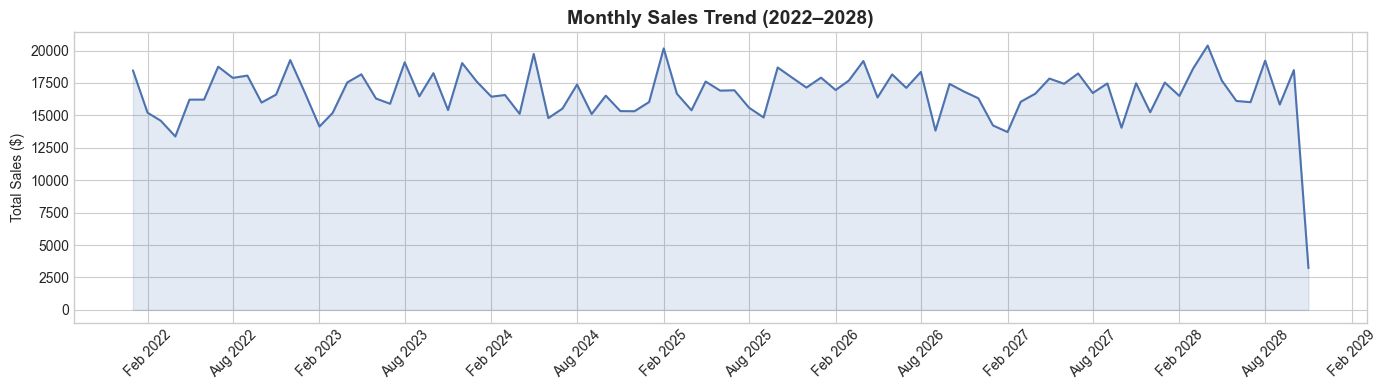

Saved: plot_monthly_trend.png


In [13]:
plt.style.use("seaborn-v0_8-whitegrid")

# ── Central color configuration ───────────────────────────────────────────────
# Each category has a fixed color used consistently across every visualization.
PRODUCT_COLORS = {
    "Widget A": "#4C72B0",   # blue
    "Widget B": "#DD8452",   # orange
    "Widget C": "#55A868",   # green
    "Widget D": "#C44E52",   # red
}
REGION_COLORS = {
    "East":  "#8172B2",      # purple
    "North": "#937860",      # tan
    "South": "#DA8BC3",      # pink
    "West":  "#CCB974",      # gold
}
GENDER_COLORS = {
    "Female": "#E377C2",     # rose
    "Male":   "#7F7F7F",     # steel grey
}
AGE_COLORS = {
    "18\u201330": "#AEC6E8", # light blue
    "31\u201345": "#4C72B0", # medium blue
    "46\u201360": "#1C4E8A", # dark blue
    "61\u201370": "#0A2444", # very dark blue
}

# ── Plot 1: Monthly Sales Trend ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
monthly = df.groupby(df["Date"].dt.to_period("M"))["Sales"].sum()
monthly.index = monthly.index.to_timestamp()
ax.plot(monthly.index, monthly.values, color="#4C72B0", linewidth=1.5)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color="#4C72B0")
ax.set_title("Monthly Sales Trend (2022\u20132028)", fontsize=14, fontweight="bold")
ax.set_ylabel("Total Sales ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot_monthly_trend.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: plot_monthly_trend.png")


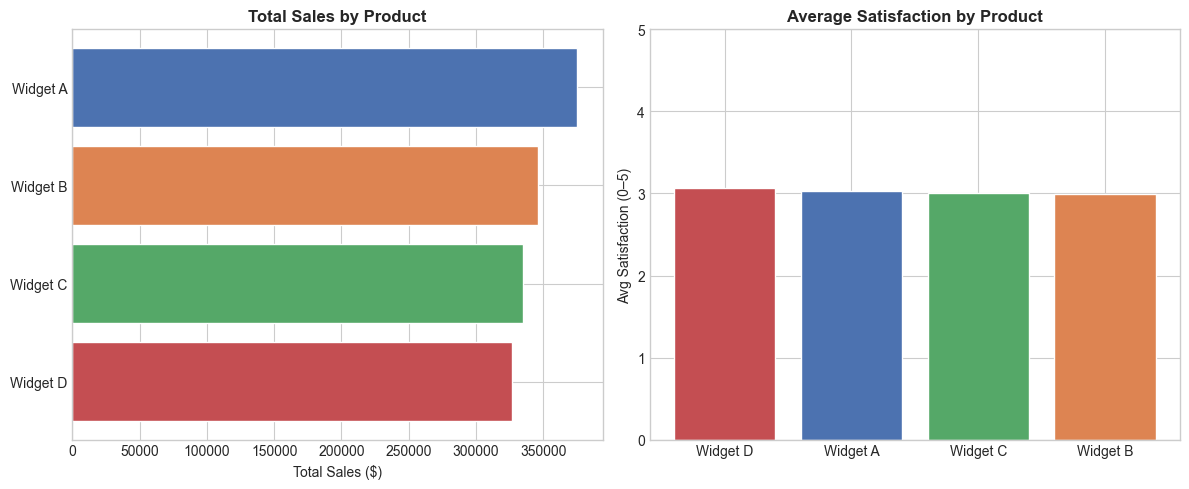

Saved: plot_product_performance.png


In [14]:
# ── Plot 2: Product Performance ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

product_totals = df.groupby("Product")["Sales"].sum().sort_values(ascending=True)
axes[0].barh(
    product_totals.index,
    product_totals.values,
    color=[PRODUCT_COLORS[p] for p in product_totals.index],
    edgecolor="white"
)
axes[0].set_title("Total Sales by Product", fontweight="bold")
axes[0].set_xlabel("Total Sales ($)")

product_sat = df.groupby("Product")["Customer_Satisfaction"].mean().sort_values(ascending=False)
axes[1].bar(
    product_sat.index,
    product_sat.values,
    color=[PRODUCT_COLORS[p] for p in product_sat.index],
    edgecolor="white"
)
axes[1].set_title("Average Satisfaction by Product", fontweight="bold")
axes[1].set_ylabel("Avg Satisfaction (0\u20135)")
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.savefig("plot_product_performance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: plot_product_performance.png")


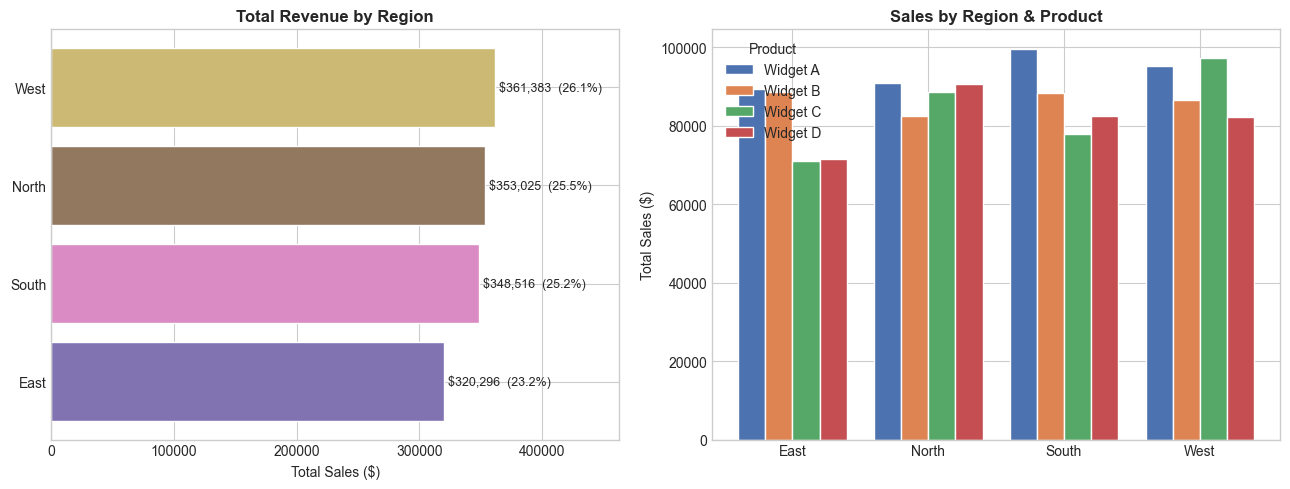

Saved: plot_regional_analysis.png


In [15]:
# ── Plot 3: Regional Analysis ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: horizontal bar chart of revenue share — replaces pie chart.
# Bars are sorted largest-first and labelled with both $ and %.
region_totals = df.groupby("Region")["Sales"].sum().sort_values(ascending=True)
total_rev = region_totals.sum()
bar_colors = [REGION_COLORS[r] for r in region_totals.index]
bars = axes[0].barh(
    region_totals.index, region_totals.values,
    color=bar_colors, edgecolor="white"
)
for bar, val in zip(bars, region_totals.values):
    axes[0].text(
        bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}  ({val/total_rev*100:.1f}%)",
        va="center", fontsize=9
    )
axes[0].set_title("Total Revenue by Region", fontweight="bold")
axes[0].set_xlabel("Total Sales ($)")
axes[0].set_xlim(0, region_totals.max() * 1.28)

# Right: grouped bar chart — Sales by Region & Product
region_product = df.groupby(["Region", "Product"])["Sales"].sum().unstack()
x = np.arange(len(region_product))
width = 0.2
for i, product in enumerate(region_product.columns):
    axes[1].bar(
        x + i * width,
        region_product[product],
        width=width,
        label=product,
        color=PRODUCT_COLORS[product],
        edgecolor="white"
    )
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(region_product.index, rotation=0)
axes[1].set_title("Sales by Region & Product", fontweight="bold")
axes[1].set_ylabel("Total Sales ($)")
axes[1].legend(title="Product")

plt.tight_layout()
plt.savefig("plot_regional_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: plot_regional_analysis.png")


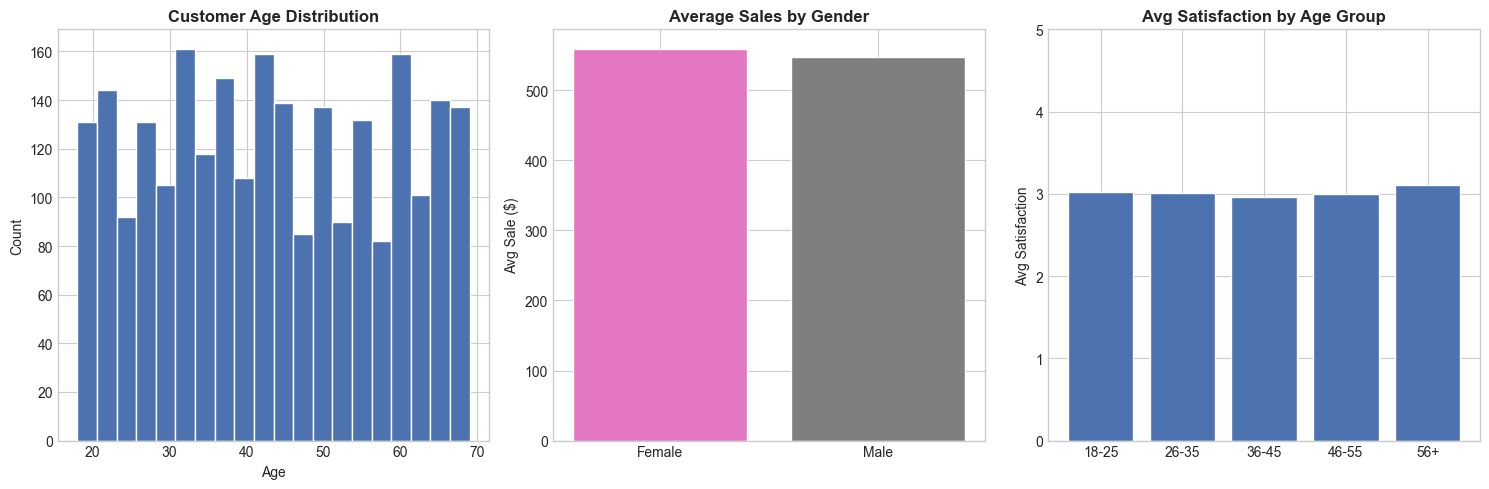

Saved: plot_customer_demographics.png


In [16]:
# ── Plot 4: Customer Demographics ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age distribution — neutral single color (not a category, so no color map needed)
axes[0].hist(df["Customer_Age"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_title("Customer Age Distribution", fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Average sales by gender
gender_sales = df.groupby("Customer_Gender")["Sales"].mean()
axes[1].bar(
    gender_sales.index, gender_sales.values,
    color=[GENDER_COLORS[g] for g in gender_sales.index],
    edgecolor="white"
)
axes[1].set_title("Average Sales by Gender", fontweight="bold")
axes[1].set_ylabel("Avg Sale ($)")

# Average satisfaction by age group
age_sat = df.groupby("Age_Group", observed=True)["Customer_Satisfaction"].mean()
axes[2].bar(
    age_sat.index.astype(str), age_sat.values,
    color=[AGE_COLORS.get(str(g), "#4C72B0") for g in age_sat.index],
    edgecolor="white"
)
axes[2].set_title("Avg Satisfaction by Age Group", fontweight="bold")
axes[2].set_ylabel("Avg Satisfaction")
axes[2].set_ylim(0, 5)

plt.tight_layout()
plt.savefig("plot_customer_demographics.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: plot_customer_demographics.png")


## Cell 10b: Sales Forecasting

> Fits a Ridge regression model with seasonal features on monthly aggregated sales,
> generates a 12-month forward forecast with 95% confidence bands,
> and embeds the results into the knowledge base.

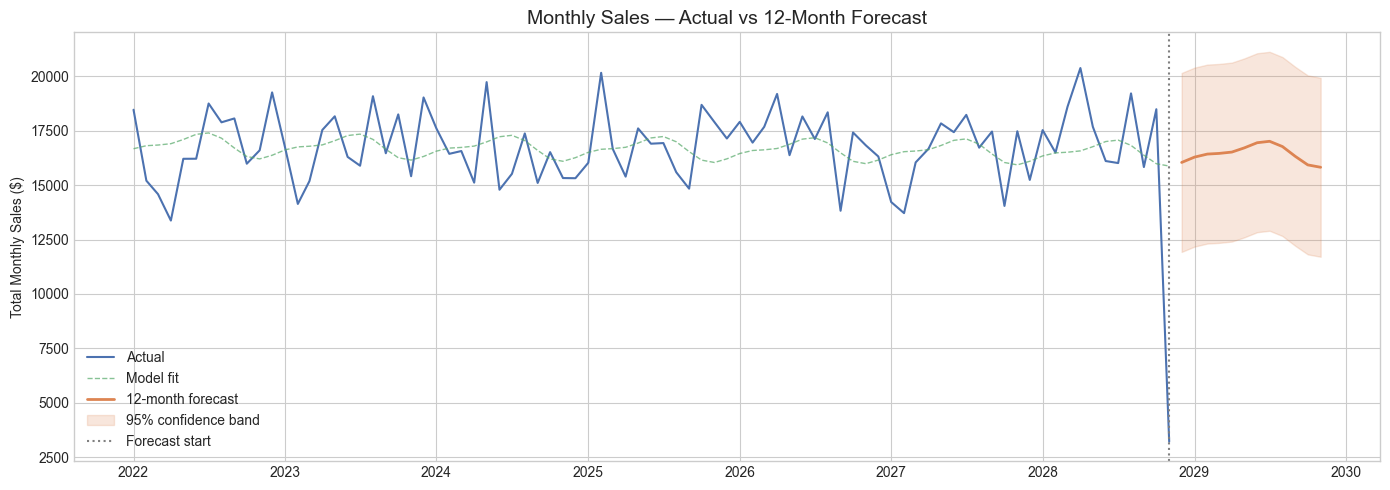


Model R² (in-sample): 0.0339
Residual std dev:     $2,098.58  (95% CI ± $4,113.21)

Date             Forecast        Lower        Upper
--------------------------------------------------
2028-12      $  16,046.78 $  11,933.57 $  20,160.00
2029-01      $  16,292.11 $  12,178.90 $  20,405.32
2029-02      $  16,432.10 $  12,318.89 $  20,545.32
2029-03      $  16,462.00 $  12,348.79 $  20,575.21
2029-04      $  16,523.69 $  12,410.48 $  20,636.91
2029-05      $  16,716.57 $  12,603.36 $  20,829.78
2029-06      $  16,953.74 $  12,840.53 $  21,066.96
2029-07      $  17,019.30 $  12,906.09 $  21,132.52
2029-08      $  16,777.30 $  12,664.09 $  20,890.52
2029-09      $  16,325.34 $  12,212.13 $  20,438.55
2029-10      $  15,934.41 $  11,821.20 $  20,047.63
2029-11      $  15,825.20 $  11,711.98 $  19,938.41

Predicted total revenue (next 12 months): $197,309
Peak forecast month:   July 2029
Trough forecast month: November 2029


In [17]:
# ── Cell 10b: Sales Forecasting (linear regression + seasonal features) ──────
# Model: Ridge regression with a linear time index + sin/cos seasonality terms.
# No extra dependencies — scikit-learn ships with every standard Python install.

from sklearn.linear_model import Ridge
import numpy as np

# Monthly aggregation
monthly = (df.groupby(df['Date'].dt.to_period('M'))['Sales']
             .sum()
             .reset_index())
monthly.columns = ['YearMonth', 'Sales']
monthly['Date'] = monthly['YearMonth'].dt.to_timestamp()
monthly = monthly.sort_values('Date').reset_index(drop=True)

# Feature engineering
#   t        — linear trend (months since first record)
#   sin/cos12 — annual seasonality (12-month cycle)
#   sin/cos6  — semi-annual seasonality (6-month cycle)
monthly['t']      = np.arange(len(monthly))
monthly['month']  = monthly['Date'].dt.month
monthly['sin12']  = np.sin(2 * np.pi * monthly['month'] / 12)
monthly['cos12']  = np.cos(2 * np.pi * monthly['month'] / 12)
monthly['sin6']   = np.sin(2 * np.pi * monthly['month'] / 6)
monthly['cos6']   = np.cos(2 * np.pi * monthly['month'] / 6)

FEATURES = ['t', 'sin12', 'cos12', 'sin6', 'cos6']
X = monthly[FEATURES].values
y = monthly['Sales'].values

model = Ridge(alpha=1.0)
model.fit(X, y)

# In-sample fit & residual std for confidence interval
y_fit     = model.predict(X)
resid_std = (y - y_fit).std()
ci_95     = 1.96 * resid_std

# ── 12-month forward forecast ─────────────────────────────────────────────────
last_date      = monthly['Date'].max()
forecast_dates = pd.date_range(last_date + pd.DateOffset(months=1),
                               periods=12, freq='MS')
forecast_t     = np.arange(len(monthly), len(monthly) + 12)
fm             = forecast_dates.month
X_future = np.column_stack([
    forecast_t,
    np.sin(2 * np.pi * fm / 12), np.cos(2 * np.pi * fm / 12),
    np.sin(2 * np.pi * fm / 6),  np.cos(2 * np.pi * fm / 6),
])
forecast_vals = model.predict(X_future)

forecast_df = pd.DataFrame({
    'Date':     forecast_dates,
    'Forecast': forecast_vals.round(2),
    'Lower':    (forecast_vals - ci_95).round(2),
    'Upper':    (forecast_vals + ci_95).round(2),
})

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly['Date'], y,      color='#4C72B0', linewidth=1.5, label='Actual')
ax.plot(monthly['Date'], y_fit,  color='#55A868', linewidth=1,
        linestyle='--', alpha=0.7, label='Model fit')
ax.plot(forecast_df['Date'], forecast_df['Forecast'],
        color='#DD8452', linewidth=2, label='12-month forecast')
ax.fill_between(forecast_df['Date'],
                forecast_df['Lower'], forecast_df['Upper'],
                color='#DD8452', alpha=0.2, label='95% confidence band')
ax.axvline(last_date, color='grey', linestyle=':', linewidth=1.5,
           label='Forecast start')

ax.set_title('Monthly Sales — Actual vs 12-Month Forecast', fontsize=14)
ax.set_ylabel('Total Monthly Sales ($)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print forecast table ──────────────────────────────────────────────────────
print(f"\nModel R² (in-sample): {model.score(X, y):.4f}")
print(f"Residual std dev:     ${resid_std:,.2f}  (95% CI ± ${ci_95:,.2f})")
print(f"\n{'Date':<12} {'Forecast':>12} {'Lower':>12} {'Upper':>12}")
print("-" * 50)
for _, row in forecast_df.iterrows():
    print(f"{row['Date'].strftime('%Y-%m'):<12} "
          f"${row['Forecast']:>11,.2f} "
          f"${row['Lower']:>11,.2f} "
          f"${row['Upper']:>11,.2f}")

predicted_annual = forecast_df['Forecast'].sum()
print(f"\nPredicted total revenue (next 12 months): ${predicted_annual:,.0f}")
peak_month = forecast_df.loc[forecast_df['Forecast'].idxmax(), 'Date']
trough_month = forecast_df.loc[forecast_df['Forecast'].idxmin(), 'Date']
print(f"Peak forecast month:   {peak_month.strftime('%B %Y')}")
print(f"Trough forecast month: {trough_month.strftime('%B %Y')}")


In [18]:
# ── Embed forecast results into the knowledge base ───────────────────────────
# Adds two documents so the RAG chain can answer forecast questions directly.

forecast_rows = "\n".join(
    f"  {r['Date'].strftime('%B %Y')}: ${r['Forecast']:,.0f} "
    f"(95% CI: ${r['Lower']:,.0f}–${r['Upper']:,.0f})"
    for _, r in forecast_df.iterrows()
)

trend_direction = "upward" if model.coef_[0] > 0 else "downward"
monthly_trend   = abs(model.coef_[0])

forecast_docs = [
    Document(
        page_content=(
            f"12-month sales forecast (Ridge regression, R²={model.score(X, y):.3f}).\n"
            f"Overall trend: {trend_direction} at approximately "
            f"${monthly_trend:,.2f} per month.\n"
            f"Predicted total revenue over the next 12 months: "
            f"${forecast_df['Forecast'].sum():,.0f}.\n"
            f"95% confidence interval width: ±${ci_95:,.0f} per month.\n"
            f"Peak forecast month: "
            f"{forecast_df.loc[forecast_df['Forecast'].idxmax(), 'Date'].strftime('%B %Y')}. "
            f"Trough: "
            f"{forecast_df.loc[forecast_df['Forecast'].idxmin(), 'Date'].strftime('%B %Y')}.\n"
            f"Monthly breakdown:\n{forecast_rows}"
        ),
        metadata={"type": "forecast", "topic": "12_month_forecast"}
    ),
    Document(
        page_content=(
            f"Sales forecasting methodology: Ridge regression with a linear time index "
            f"and sine/cosine seasonal features (12-month and 6-month cycles). "
            f"Trained on {len(monthly)} months of historical data "
            f"({monthly['Date'].min().strftime('%B %Y')} to "
            f"{monthly['Date'].max().strftime('%B %Y')}). "
            f"In-sample R²: {model.score(X, y):.3f}. "
            f"Residual std dev: ${resid_std:,.2f}. "
            f"The model captures the long-run trend and recurring seasonal patterns "
            f"but does not account for external shocks or structural breaks."
        ),
        metadata={"type": "forecast", "topic": "forecast_methodology"}
    ),
]

vectorstore.add_documents(forecast_docs)
vectorstore.save_local("faiss_knowledge_index")

total = vectorstore.index.ntotal
print(f"Forecast documents added. Knowledge base now contains {total:,} vectors.")
print("Users can now ask: 'What do you predict for sales next year?'")


Forecast documents added. Knowledge base now contains 27 vectors.
Users can now ask: 'What do you predict for sales next year?'


---
## Cell 11: Streamlit UI

> **Step 7 (Part 2):** Save this cell's content to `app.py`, then run `streamlit run app.py` in your terminal.

The cell below writes the Streamlit app file to disk automatically.

In [19]:
streamlit_app = """
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv
from sklearn.linear_model import Ridge

from langchain_core.documents import Document
from langchain.chains import RetrievalQA, ConversationalRetrievalChain
from langchain.memory import ConversationBufferMemory
from langchain_anthropic import ChatAnthropic
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import FastEmbedEmbeddings
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain.agents.agent_types import AgentType

load_dotenv()

# ── Consistent color maps ─────────────────────────────────────────────────────
PRODUCT_COLORS = {
    "Widget A": "#4C72B0",
    "Widget B": "#DD8452",
    "Widget C": "#55A868",
    "Widget D": "#C44E52",
}
REGION_COLORS = {
    "East":  "#8172B2",
    "North": "#937860",
    "South": "#DA8BC3",
    "West":  "#CCB974",
}
GENDER_COLORS = {"Female": "#E377C2", "Male": "#7F7F7F"}
AGE_COLORS = {
    "18\u201330": "#AEC6E8",
    "31\u201345": "#4C72B0",
    "46\u201360": "#1C4E8A",
    "61\u201370": "#0A2444",
}

st.set_page_config(page_title="InsightForge BI Assistant",
                   page_icon="\U0001f4ca", layout="wide")
st.title("\U0001f4ca InsightForge \u2014 AI Business Intelligence Assistant")
st.markdown("Powered by Claude + LangChain + FAISS")
st.divider()

@st.cache_resource
def load_resources():
    import onnxruntime, fastembed
    df = pd.read_csv("sales_data.csv", parse_dates=["Date"])
    df["Year"]    = df["Date"].dt.year
    df["Month"]   = df["Date"].dt.month
    df["Quarter"] = df["Date"].dt.quarter
    df["Age_Group"] = pd.cut(df["Customer_Age"], bins=[17,30,45,60,70],
                              labels=["18\u201330","31\u201345","46\u201360","61\u201370"])
    api_key = os.getenv("ANTHROPIC_API_KEY")
    llm = ChatAnthropic(model="claude-haiku-4-5-20251001",
                        anthropic_api_key=api_key, temperature=0, max_tokens=2048)
    embeddings = FastEmbedEmbeddings()
    if os.path.exists("faiss_sales_index"):
        vectorstore = FAISS.load_local("faiss_sales_index", embeddings,
                                       allow_dangerous_deserialization=True)
    else:
        def row_to_doc(row):
            return Document(page_content=(
                f"On {row['Date'].date()}, a {row['Customer_Age']}-year-old "
                f"{row['Customer_Gender']} customer purchased {row['Product']} "
                f"in {row['Region']}. Sale: ${row['Sales']}. "
                f"Satisfaction: {row['Customer_Satisfaction']:.2f}."))
        vectorstore = FAISS.from_documents(
            [row_to_doc(r) for _, r in df.iterrows()], embeddings)
    retriever    = vectorstore.as_retriever(search_kwargs={"k": 5})
    rag_chain    = RetrievalQA.from_chain_type(llm=llm, retriever=retriever)
    pandas_agent = create_pandas_dataframe_agent(
        llm=llm, df=df,
        agent_type=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
        verbose=False, allow_dangerous_code=True)
    return df, llm, rag_chain, pandas_agent

@st.cache_data
def build_forecast(_df):
    monthly = (_df.groupby(_df["Date"].dt.to_period("M"))["Sales"]
                  .sum().reset_index())
    monthly.columns = ["YearMonth","Sales"]
    monthly["Date"]  = monthly["YearMonth"].dt.to_timestamp()
    monthly = monthly.sort_values("Date").reset_index(drop=True)
    monthly["t"]     = np.arange(len(monthly))
    monthly["month"] = monthly["Date"].dt.month
    monthly["sin12"] = np.sin(2*np.pi*monthly["month"]/12)
    monthly["cos12"] = np.cos(2*np.pi*monthly["month"]/12)
    monthly["sin6"]  = np.sin(2*np.pi*monthly["month"]/6)
    monthly["cos6"]  = np.cos(2*np.pi*monthly["month"]/6)
    FEATURES = ["t","sin12","cos12","sin6","cos6"]
    X = monthly[FEATURES].values; y = monthly["Sales"].values
    model = Ridge(alpha=1.0); model.fit(X, y)
    y_fit     = model.predict(X)
    resid_std = (y - y_fit).std()
    ci_95     = 1.96 * resid_std
    last_date      = monthly["Date"].max()
    forecast_dates = pd.date_range(last_date + pd.DateOffset(months=1),
                                   periods=12, freq="MS")
    forecast_t = np.arange(len(monthly), len(monthly)+12)
    fm = forecast_dates.month
    Xf = np.column_stack([forecast_t,
                          np.sin(2*np.pi*fm/12), np.cos(2*np.pi*fm/12),
                          np.sin(2*np.pi*fm/6),  np.cos(2*np.pi*fm/6)])
    fv = model.predict(Xf)
    forecast_df = pd.DataFrame({"Date": forecast_dates,
                                 "Forecast": fv.round(2),
                                 "Lower": (fv-ci_95).round(2),
                                 "Upper": (fv+ci_95).round(2)})
    return monthly, y_fit, forecast_df, ci_95, model.score(X,y), \
           ("upward" if model.coef_[0]>0 else "downward"), model.coef_[0]

with st.spinner("Loading InsightForge..."):
    df, llm, rag_chain, pandas_agent = load_resources()

PANDAS_KW = [
    "total","sum","average","mean","median","max","min","count","how many",
    "percentage","percent","%","number of","rank","top","bottom","highest",
    "lowest","calculate","compute","trend","over time","over the","by year",
    "by month","by quarter","monthly","quarterly","annually","annual","yearly",
    "year","month","quarter","2022","2023","2024","2025","2026","growth","grew",
    "increase","increased","decrease","decreased","change","changed","compare",
    "comparison","versus"," vs ","difference","breakdown","distribution",
    "by region","by product","by gender","by age","which region","which product",
    "forecast","predict","projection","next year","next month",
]

def route_and_answer(q):
    if any(kw in q.lower() for kw in PANDAS_KW):
        return pandas_agent.invoke(q)["output"], "Pandas Agent"
    return rag_chain.invoke({"query": q})["result"], "RAG Chain"

with st.sidebar:
    st.header("\U0001f4c8 Dataset Summary")
    st.metric("Total Records",    f"{len(df):,}")
    st.metric("Date Range",       f"{df['Date'].min().year}\u2013{df['Date'].max().year}")
    st.metric("Total Revenue",    f"${df['Sales'].sum():,.0f}")
    st.metric("Avg Satisfaction", f"{df['Customer_Satisfaction'].mean():.2f} / 5")
    st.divider()
    st.subheader("Columns")
    st.write(list(df.columns[:7]))

tab1, tab2, tab3, tab4 = st.tabs([
    "\U0001f4ac Ask InsightForge",
    "\U0001f4ca Visualisations",
    "\U0001f52e Forecast",
    "\U0001f5c2\ufe0f Raw Data",
])

with tab1:
    st.subheader("Ask a business question")
    st.markdown("*Examples: 'What is total revenue by region?' or 'Which product sells best?'*")
    if "messages" not in st.session_state:
        st.session_state.messages = []
    for msg in st.session_state.messages:
        with st.chat_message(msg["role"]):
            st.write(msg["content"])
    if prompt := st.chat_input("Ask InsightForge..."):
        st.session_state.messages.append({"role": "user", "content": prompt})
        with st.chat_message("user"):
            st.write(prompt)
        with st.chat_message("assistant"):
            with st.spinner("Thinking..."):
                answer, route = route_and_answer(prompt)
            st.write(answer)
            st.caption(f"Answered via: {route}")
        st.session_state.messages.append({"role": "assistant", "content": answer})

with tab2:
    st.subheader("Sales Analytics Dashboard")
    plt.style.use("seaborn-v0_8-whitegrid")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Monthly Sales Trend**")
        monthly_plot = df.groupby(df["Date"].dt.to_period("M"))["Sales"].sum()
        monthly_plot.index = monthly_plot.index.to_timestamp()
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.plot(monthly_plot.index, monthly_plot.values, color="#4C72B0")
        ax.fill_between(monthly_plot.index, monthly_plot.values, alpha=0.15, color="#4C72B0")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.xticks(rotation=45); plt.tight_layout(); st.pyplot(fig)

    with col2:
        st.markdown("**Total Sales by Product**")
        prod = df.groupby("Product")["Sales"].sum().sort_values()
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.barh(prod.index, prod.values,
                color=[PRODUCT_COLORS[p] for p in prod.index], edgecolor="white")
        plt.tight_layout(); st.pyplot(fig)

    col3, col4 = st.columns(2)

    with col3:
        st.markdown("**Total Revenue by Region**")
        reg = df.groupby("Region")["Sales"].sum().sort_values(ascending=True)
        total_rev = reg.sum()
        fig, ax = plt.subplots(figsize=(5, 4))
        bars = ax.barh(reg.index, reg.values,
                       color=[REGION_COLORS[r] for r in reg.index], edgecolor="white")
        for bar, val in zip(bars, reg.values):
            ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                    f"{val/total_rev*100:.1f}%", va="center", fontsize=9)
        ax.set_xlim(0, reg.max()*1.2)
        plt.tight_layout(); st.pyplot(fig)

    with col4:
        st.markdown("**Avg Satisfaction by Age Group**")
        age_sat = df.groupby("Age_Group", observed=True)["Customer_Satisfaction"].mean()
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.bar(age_sat.index.astype(str), age_sat.values,
               color=[AGE_COLORS.get(str(g), "#4C72B0") for g in age_sat.index],
               edgecolor="white")
        ax.set_ylim(0, 5); ax.set_ylabel("Avg Satisfaction")
        plt.tight_layout(); st.pyplot(fig)

with tab3:
    st.subheader("\U0001f52e 12-Month Sales Forecast")
    monthly_hist, y_fit, forecast_df, ci_95, r2, trend_dir, monthly_coef = build_forecast(df)
    col1, col2, col3 = st.columns(3)
    col1.metric("Model R\u00b2 (fit quality)", f"{r2:.3f}")
    col2.metric("Trend direction", trend_dir.capitalize(),
                delta=f"${abs(monthly_coef):,.0f}/month")
    col3.metric("Predicted next-12-month revenue", f"${forecast_df['Forecast'].sum():,.0f}")
    st.markdown("---")
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(monthly_hist["Date"], monthly_hist["Sales"],
            color="#4C72B0", linewidth=1.5, label="Actual")
    ax.plot(monthly_hist["Date"], y_fit, color="#55A868", linewidth=1,
            linestyle="--", alpha=0.7, label="Model fit")
    ax.plot(forecast_df["Date"], forecast_df["Forecast"],
            color="#DD8452", linewidth=2, label="Forecast")
    ax.fill_between(forecast_df["Date"], forecast_df["Lower"], forecast_df["Upper"],
                    color="#DD8452", alpha=0.2, label="95% confidence band")
    ax.axvline(monthly_hist["Date"].max(), color="grey", linestyle=":",
               linewidth=1.5, label="Forecast start")
    ax.set_title("Monthly Sales \u2014 Actual vs 12-Month Forecast", fontsize=13)
    ax.set_ylabel("Monthly Sales ($)")
    ax.legend(fontsize=9); plt.tight_layout(); st.pyplot(fig)
    st.markdown("**Monthly forecast breakdown**")
    disp = forecast_df.copy()
    disp["Date"] = disp["Date"].dt.strftime("%B %Y")
    disp.columns = ["Month","Forecast ($)","Lower 95% CI ($)","Upper 95% CI ($)"]
    st.dataframe(disp.set_index("Month"), use_container_width=True)

with tab4:
    st.subheader("Sales Data")
    st.dataframe(df.drop(columns=["Age_Group","YearMonth"], errors="ignore"), height=400)
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_app)
print("Streamlit app written to app.py")
print("Launch with:  streamlit run app.py")


Streamlit app written to app.py
Launch with:  streamlit run app.py


---
## ✅ Project Complete

| Capstone Step | Status | Implementation |
|---|---|---|
| 1. Data preparation | ✅ | Cell 3 — load, parse dates, derived columns |
| 2. Knowledge base creation | ✅ | Cell 4 — FAISS vector store |
| 3. LLM application development | ✅ | Cells 5, 6, 8 — Pandas agent, RAG, summaries |
| 4. Chain prompts | ✅ | Cell 6 — `RAG_PROMPT_TEMPLATE` |
| 5. RAG system setup | ✅ | Cells 4, 6 — FAISS + `RetrievalQA` |
| 6. Memory integration | ✅ | Cell 7 — `ConversationBufferMemory` |
| 7. Model evaluation | ✅ | Cell 9 — `QAEvalChain` |
| 7. Data visualisations | ✅ | Cell 10 — 4 matplotlib plots |
| 7. Streamlit UI | ✅ | Cell 11 — full chat + dashboard app |